In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/bensalem14/sgcc-dataset/datasetsmall.csv')

In [5]:
df.head()

,01/01/2014,01/02/2014,01/03/2014,01/04/2014,01/05/2014,01/06/2014,01/07/2014,01/08/2014,01/09/2014,01/10/2014,...,1/19/2014,1/20/2014,1/21/2014,1/22/2014,1/23/2014,1/24/2014,1/25/2014,1/26/2014,CONS_NO,FLAG
0,2401.0,2500.0,2674.0,2432.00,2231.00,1942.00,2752.00,1244.00,2069.0,2360.0,...,1774.00,2089.0,1300.0,2419.0,2462.0,1177.00,340.00,2272.00,A0E791400CF1C48C43DC26A68227854A,1
1,3318.0,282.0,540.0,5670.00,4854.00,4170.00,4848.00,3546.00,4416.0,3966.0,...,3876.00,3228.0,3054.0,3840.0,1422.0,1956.00,1380.00,96.00,B415F931D3BFB17ACEF48BC648B04FC2,1
2,1020.8,1097.4,1377.4,1408.80,1414.80,1387.40,1444.60,1325.00,1461.6,1253.2,...,1214.60,1285.4,1279.6,1188.6,1362.6,1286.00,1267.60,1444.00,DE8E1EAE4E578C0CEF92D1E23499888F,1
3,0.0,1183.8,1190.4,1183.80,0.00,1154.40,1166.40,1183.80,1169.4,1174.2,...,0.00,1072.8,1090.8,1090.2,1101.0,1079.40,1121.40,1145.40,2952491E940C9040B188B3C9095910D6,0
4,1445.7,1348.2,1281.9,1276.35,1219.95,1289.85,1298.55,1326.15,1410.6,1376.7,...,1331.85,1392.9,1213.2,1463.1,1405.5,1240.05,1190.25,1455.45,DBEED8FD0E7F5E0D1BAF1F86F4983459,1


In [6]:
#Dropping the "CONS_NO"
df.drop(columns='CONS_NO', inplace=True)

#Converting FLAG column to integer type
df['FLAG'] = df['FLAG'].astype(int)

In [7]:
from scipy import stats
#Handling missing values
#Interpolating missing values along the column

df.interpolate(method='linear', axis=1, inplace=True)

In [9]:
import numpy as np

#Excluding 'FLAG' column from outlier detection
data_without_flag = df.drop(columns=['FLAG'])

#Outlier detection and removal using Z-score
#Defining a threshold for the Z-Score (eg. 3)
z_threshold = 3
z_scores = stats.zscore(data_without_flag)
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < z_threshold).all(axis=1)
df = df[filtered_entries]

#Checking the shape of the dataframe after outlier removal
print("Shape of dataframe after outlier removal: ", df.shape)

Shape of dataframe after outlier removal:  (25677, 27)


In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#Normalization
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df)

#Standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(df)

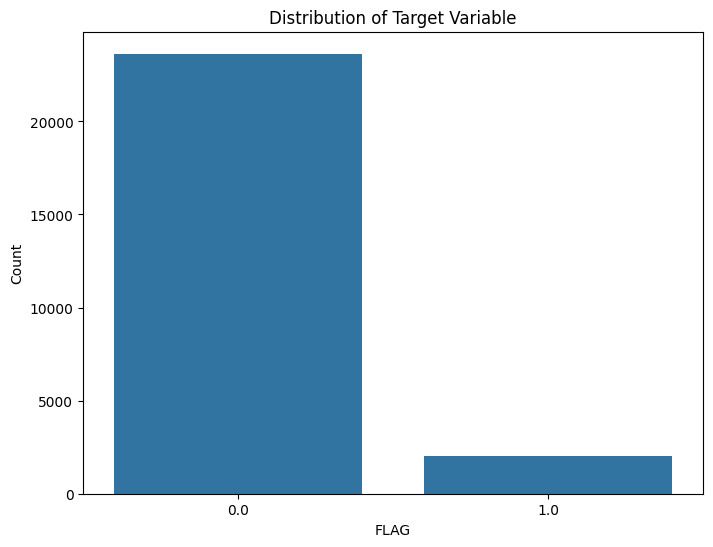

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

#Plotting to check if there's class imbalance
plt.figure(figsize=(8,6))
sns.countplot(x='FLAG', data=df)
plt.title("Distribution of Target Variable")
plt.xlabel("FLAG")
plt.ylabel("Count")
plt.show()

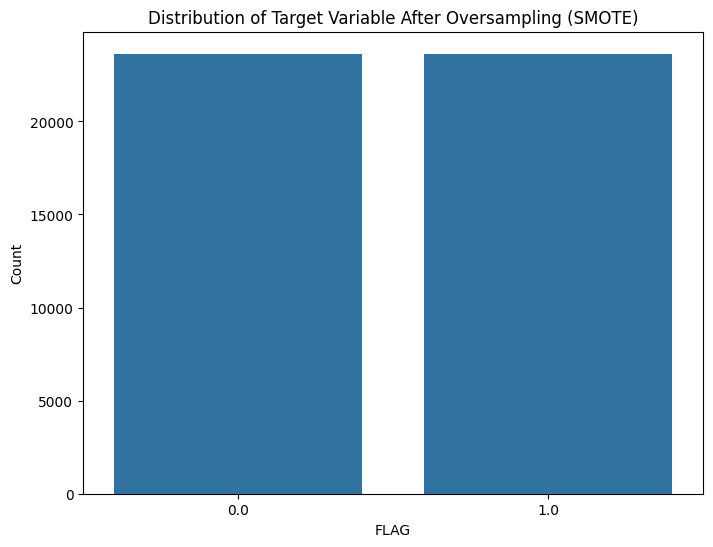

In [12]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features (X) and target variable (y)
X = df.drop(columns=['FLAG'])
y = df['FLAG']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Concatenate resampled features and target variable into a new DataFrame
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='FLAG')], axis=1)

# Visualize the distribution of the target variable after oversampling
plt.figure(figsize=(8, 6))
sns.countplot(x='FLAG', data=df_resampled)
plt.title('Distribution of Target Variable After Oversampling (SMOTE)')
plt.xlabel('FLAG')
plt.ylabel('Count')
plt.show()

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary Statistics
summary_stats = df.describe()
print("Summary Statistics:")
print(summary_stats)

Summary Statistics:
         01/01/2014    01/02/2014    01/03/2014    01/04/2014    01/05/2014  \
count  25677.000000  25677.000000  25677.000000  25677.000000  25677.000000   
mean       5.917133      5.749367      5.384465      5.619891      5.941839   
std        8.265382      7.900125      7.532985      7.808352      8.024857   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        3.270000      3.360000      3.060000      3.290000      3.500000   
75%        8.800000      8.450000      7.980000      8.200000      8.750000   
max       99.320000     93.880000     99.690000    126.330000    108.290000   

         01/06/2014    01/07/2014    01/08/2014    01/09/2014    01/10/2014  \
count  25677.000000  25677.000000  25677.000000  25677.000000  25677.000000   
mean       5.601464      5.445547      5.499287      5.570514      5.494675   
std        7.689665      7.6916

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE

# Separate features (X) and target variable (y)
X = df.drop(columns=['FLAG'])
y = df['FLAG']

# Apply SMOTE to address class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize SVM classifier with rbf kernel
svc = SVC(kernel='rbf')

# Fit the model to the training data
svc.fit(X_train, y_train)

# Predict using the trained model on the test data
y_pred = svc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[3035 1657]
 [1556 3206]]


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
# Compute classification report
report = classification_report(y_test, y_pred)

# Print classification report
print('Classification Report:')
print(report)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.65      0.65      4692
         1.0       0.66      0.67      0.67      4762

    accuracy                           0.66      9454
   macro avg       0.66      0.66      0.66      9454
weighted avg       0.66      0.66      0.66      9454



In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski')
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[3310 1382]
 [ 551 4211]]


In [17]:
# Compute classification report
report = classification_report(y_test, y_pred)

# Print classification report
print('Classification Report:')
print(report)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.71      0.77      4692
         1.0       0.75      0.88      0.81      4762

    accuracy                           0.80      9454
   macro avg       0.81      0.79      0.79      9454
weighted avg       0.80      0.80      0.79      9454



In [18]:
from sklearn.tree import DecisionTreeClassifier
# Initialize Decision Tree Classifier
dtc = DecisionTreeClassifier(criterion='entropy')

# Fit the model to the training data
dtc.fit(X_train, y_train)

# Predict using the trained model on the test data
y_pred = dtc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print('Confusion Matrix:')
print(cm)

# Compute classification report
report = classification_report(y_test, y_pred)

# Print classification report
print('Classification Report:')
print(report)

Confusion Matrix:
[[3838  854]
 [1149 3613]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.82      0.79      4692
         1.0       0.81      0.76      0.78      4762

    accuracy                           0.79      9454
   macro avg       0.79      0.79      0.79      9454
weighted avg       0.79      0.79      0.79      9454



In [20]:
from sklearn.ensemble import RandomForestClassifier
# Initialize RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50, criterion='entropy')

# Fit the model to the training data
rfc.fit(X_train, y_train)

# Predict using the trained model on the test data
y_pred = rfc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print('Confusion Matrix:')
print(cm)

# Compute classification report
report = classification_report(y_test, y_pred)

# Print classification report
print('Classification Report:')
print(report)

Confusion Matrix:
[[4350  342]
 [ 749 4013]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89      4692
         1.0       0.92      0.84      0.88      4762

    accuracy                           0.88      9454
   macro avg       0.89      0.88      0.88      9454
weighted avg       0.89      0.88      0.88      9454



In [21]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost modelini tanımla
xgb = xgb.XGBClassifier()

# Modeli eğit
xgb.fit(X_train, y_train)

# Test seti üzerinde tahmin yap
y_pred = xgb.predict(X_test)

# Performans metriklerini yazdır
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8323460968902052

Confusion Matrix:
[[3969  723]
 [ 862 3900]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.85      0.83      4692
         1.0       0.84      0.82      0.83      4762

    accuracy                           0.83      9454
   macro avg       0.83      0.83      0.83      9454
weighted avg       0.83      0.83      0.83      9454

